In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import fmatoolbox as fma
import xarray as xr
import itertools
import scipy as sp
import warnings

import sys
import pathlib
sys.path.append(str(pathlib.Path.cwd().parent.parent))
import ISRUtilities as isru
froot = pathlib.Path().cwd().parent.parent / 'Results/Figures/ISAHpcPfc'
batch_file = '/mnt/hubel-data-103/Pietro/InfraSlowNRPaper/Data/IS_intervals.batch'
do_save = False

In [2]:
def _laggedSpikeCrossCorr(session,regs=None,event='deltaWaves',bin=0.1,n_bins=11,step=7,target=0,shift=-1,pairs=None):
    # compute lagged cross-region pairwise unit correlation around event times as (shuffle, region, lag) XArray
    # time resolution will be 'bin' / 'step'
    # 'shuffle' coordinate is False iff corresponding data values are real

    R = fma.regions.regions(session,events=['InfraSlowRhythm/infraslowaval'])
    regs = R.ids if regs is None else np.array(regs)
    if event in ['ripples','deltaWaves','spindles','down']:
        event_t = isru.loadHpcPfcEvents(session,names=event,regions=R)[event]
    else:
        isa = R.eventIntervals('slownr')
        on = R.eventIntervals('slowavalnr')
        event_t = isru.ISTransitions(isa,on)[int(event=='on_off')] # CHECK

    # make region pairs
    if pairs is None:
        reg_pair_idx = [list(p) for p in itertools.combinations(range(len(regs)),2)] # make pairs preserving order
        reg_pair_idx = reg_pair_idx + [p[::-1] for p in reg_pair_idx] # add reverse
    else:
        reg_pair_idx = pairs
    reg_pairs = [f'{regs[rp[0]]}-{regs[rp[1]]}' for rp in reg_pair_idx]
    is_reg = np.isin(regs,R.ids) # is_reg[i] is True if regs[i] is in R.ids
    unit_range = {regs[i]: [R.spikes(regs[i])[:,1].min(),R.spikes(regs[i])[:,1].max()] if r else None for i, r in enumerate(is_reg)}

    # 1. count spikes in overlapping windows around event times
    limits = (-n_bins*bin/2, n_bins*bin/2)
    n_times = (n_bins-1) * step + 1
    peths = {}
    for j, r in enumerate(regs[is_reg]):
        s = R.spikes(r)
        peths[r], times, _ = fma.analysis.PETH(s[:,0],event_t,limits=limits,n_bins=n_bins,step=step,groups=s[:,1],g_range=unit_range[r],fast=True) # (n_ripples, n_lags, n_units)
        if n_times != len(times):
            print('!')

    # define target times
    skip = target is None
    target = np.arange(n_times) if skip else n_times//2 + np.array(target,ndmin=1) # center + offset given by 'target' input
    # If TARGET IS None: special case, results are one the .T of the other

    n_pairs = len(reg_pairs)
    spearman = np.full((2,n_pairs,n_times,len(target)),np.nan)
    for i, rp in enumerate(reg_pair_idx):
        if i < n_pairs // 2 or not skip:
            if is_reg[rp[0]] and is_reg[rp[1]]:

                ref_peth = peths[regs[rp[0]]]
                for k in [0,1]:
                    # surrogate: roll across events
                    lagged_peth = np.roll(peths[regs[rp[1]]],shift=shift,axis=0) if k else peths[regs[rp[1]]]
                    n_keep_units = lagged_peth.shape[2] # used to recover the cross-correlation block in spearmanr output

                    for sour in range(n_times):
                        for tar, t_target in enumerate(target):
                            with np.errstate(invalid='ignore'): # suppress 0 / 0 warning
                                with warnings.catch_warnings():
                                    warnings.filterwarnings('ignore', category=sp.stats.ConstantInputWarning)
                                    spr = sp.stats.spearmanr(lagged_peth[:,sour,:], ref_peth[:,t_target,:])[0]
                            spearman[k,i,sour,tar] = np.nanmean(np.abs(spr[:n_keep_units,n_keep_units:]))
    if skip:
        spearman[:,n_pairs//2:,:,:] = spearman[:,:n_pairs//2,:,:].transpose(0,1,3,2)

    spearman = xr.DataArray(spearman,dims=('shuffle','reg','lag','target'),coords={'shuffle': [False,True], 'reg': reg_pairs, 'lag': times, 'target': times[target], 'event': event, 'rat': int(R.rat)})

    return spearman

In [3]:
# test one session
# NOTE: bin 0.05 for curves, 0.1 ok for color maps
session = fma.data.readBatchFile(batch_file)[0][30]
print(f'session: {session}')
xdata = _laggedSpikeCrossCorr(session,event='down',bin=0.1,n_bins=11,step=3,target=None,shift=5)

session: /mnt/hubel-data-140/karadoc/Rat004_20240319/Rat004_20240319.xml


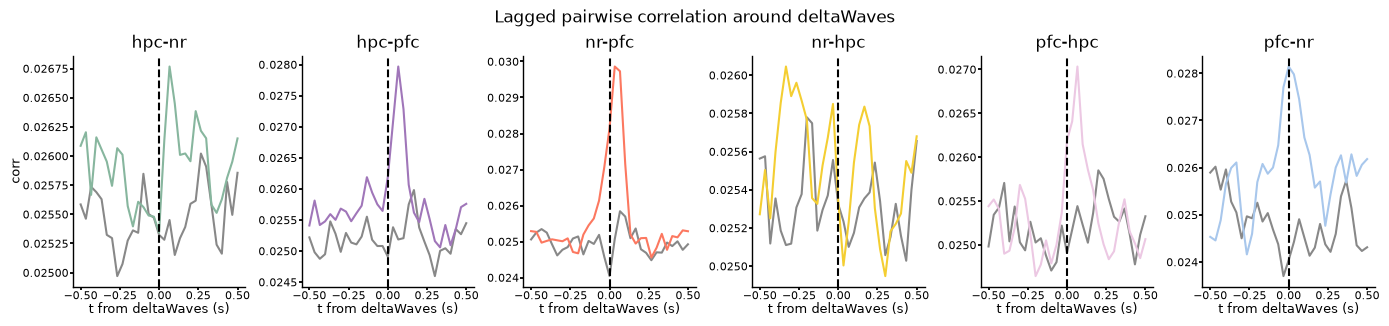

In [13]:
# interpretation: reg1 pop vector at transition correlated with reg2's delayed
fig, axs = fma.plotting.makeFigure(f'Lagged pairwise correlation around {xdata.event.values}',n=(1,6),size=(35,8))
for i, r in enumerate(xdata.reg.values):
    reg_data = xdata.sel(reg=r,target=0)
    fma.plotting.semPlot(xdata.lag,reg_data.sel(shuffle=True),zscore=False,color=isru.paperColors('shuffle'),label=str(r.item().upper()),ax=axs[i])
    axs[i].plot(xdata.lag,reg_data.sel(shuffle=False),color=isru.paperColors(i),label=str(r.item().upper()))
    axs[i].set_xlabel(f't from {xdata.event.values} (s)'), axs[i].set_title(r)
    axs[i].axvline(0,ls='--',color='k')
axs[0].set_ylabel('corr');

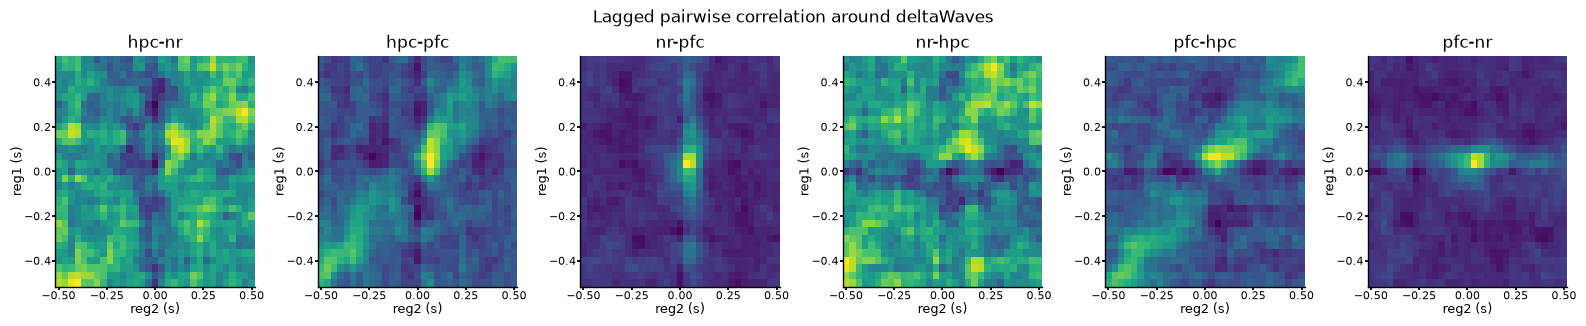

In [14]:
# interpretation: reg1 target, reg2 source
fig, ax = fma.plotting.makeFigure(f'Lagged pairwise correlation around {xdata.event.values}',n=(1,6),size=(40,8))
for i, r in enumerate(xdata.reg.values):
    reg_data = xdata.sel(reg=r)
    fma.plotting.plotColorMap(reg_data.sel(shuffle=False).T,x=reg_data.lag,y=reg_data.target,ax=ax[i])
    ax[i].set(title=r,xlabel='reg2 (s)',ylabel='reg1 (s)')

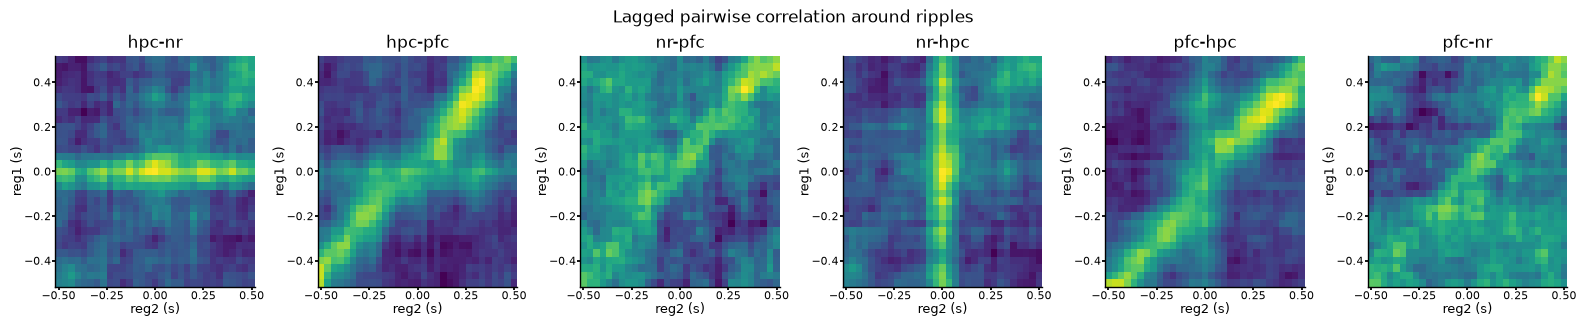

In [16]:
# see ripples
fig, ax = fma.plotting.makeFigure(f'Lagged pairwise correlation around {xdata.event.values}',n=(1,6),size=(40,8))
for i, r in enumerate(xdata.reg.values):
    reg_data = xdata.sel(reg=r)
    fma.plotting.plotColorMap(reg_data.sel(shuffle=False).T,x=reg_data.lag,y=reg_data.target,ax=ax[i])
    ax[i].set(title=r,xlabel='reg2 (s)',ylabel='reg1 (s)')

In [6]:
# test one session
session = fma.data.readBatchFile(batch_file)[0][30]
print(f'session: {session}')
xdata = _laggedSpikeCrossCorr(session,event='off_on',bin=0.1,n_bins=31,step=1,target=None,shift=5)

session: /mnt/hubel-data-140/karadoc/Rat004_20240319/Rat004_20240319.xml


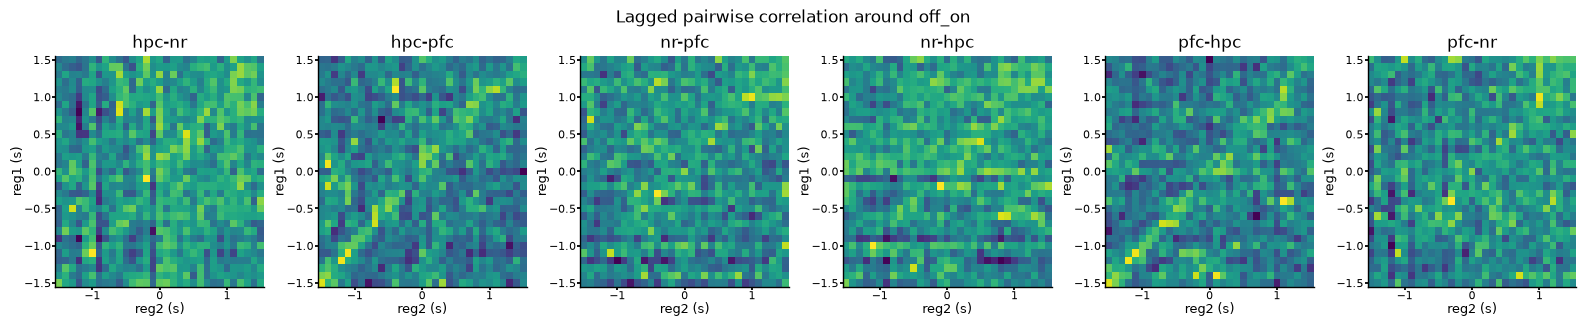

In [7]:
# see OFF-ON
fig, ax = fma.plotting.makeFigure(f'Lagged pairwise correlation around {xdata.event.values}',n=(1,6),size=(40,8))
for i, r in enumerate(xdata.reg.values):
    reg_data = xdata.sel(reg=r)
    fma.plotting.plotColorMap(reg_data.sel(shuffle=False).T,x=reg_data.lag,y=reg_data.target,ax=ax[i])
    ax[i].set(title=r,xlabel='reg2 (s)',ylabel='reg1 (s)')

batch for delta waves

In [ ]:
regs = ['hpc','nr','pfc']
corr = fma.data.runBatch(batch_file,_laggedSpikeCrossCorr,kwargs={'regs': regs, 'n_bins': 5, 'step': 3, 'target': None, 'shift': -5},parallel=True)
corr_cat = xr.concat([d for d in corr if d is not None],dim='rat',join='outer')
corr_avg = corr_cat.groupby('rat').mean(dim='rat',skipna=True)

In [ ]:
fig, axs = fma.plotting.makeFigure(n=(1,6),size=(35,7))
for i, r in enumerate(corr_avg['region'].values):
    reg_data = corr_avg.sel(region=r,target=0)
    fma.plotting.semPlot(corr_avg['lag'],reg_data.sel(shuffle=True),zscore=None,color=isru.paperColors('shuffle'),label=r.upper(),ax=axs[i])
    fma.plotting.semPlot(corr_avg['lag'],reg_data.sel(shuffle=False),zscore=None,color=isru.paperColors(i),label=r.upper(),ax=axs[i])
    # sh_mean = reg_data.sel(shuffle=True).mean(dim='lag')
    # sh_std = reg_data.sel(shuffle=True).std(dim='lag')
    # axs[i].plot(data_avg['lag'],(reg_data.sel(shuffle=True).T-sh_mean)/sh_std,color=isru.paperColors('shuffle'),label=r.upper())
    # axs[i].plot(data_avg['lag'],(reg_data.sel(shuffle=False).T-sh_mean)/sh_std,color=isru.paperColors(i),label=r.upper())
    peak_time = np.argmax(reg_data.sel(shuffle=False).mean('rat').data)
    axs[i].axvline(reg_data.lag[peak_time],ls='--',color=isru.paperColors(i)),
    axs[i].axvline(0,ls='--',color='k'), axs[i].set_xlabel('t from delta (s)'), axs[i].set_title(r)
#fma.plotting.saveFigure(fig,froot/'Figure3/Fig3g_fr_rip',['svg','png'])

In [ ]:
# DIVIDE ISA nISA
fig, axs = fma.plotting.makeFigure(n=(1,6),size=(35,7))
for i, r in enumerate(corr_avg['region'].values):
    reg_data = corr_avg.sel(region=r,target=0)
    #fma.plotting.semPlot(data_avg['lag'],reg_data.sel(shuffle=True),zscore=2,color=isru.paperColors('shuffle'),label=r.upper(),ax=axs[i])
    #fma.plotting.semPlot(data_avg['lag'],reg_data.sel(shuffle=False),zscore=2,color=isru.paperColors(i),label=r.upper(),ax=axs[i])
    # sh_mean = reg_data.sel(shuffle=True).mean(dim='lag')
    # sh_std = reg_data.sel(shuffle=True).std(dim='lag')
    # axs[i].plot(data_avg['lag'],(reg_data.sel(shuffle=True).T-sh_mean)/sh_std,color=isru.paperColors('shuffle'),label=r.upper())
    # axs[i].plot(data_avg['lag'],(reg_data.sel(shuffle=False).T-sh_mean)/sh_std,color=isru.paperColors(i),label=r.upper())
    axs[i].plot(corr_avg['lag'],reg_data.sel(shuffle=True).T,color=isru.paperColors('shuffle'),label=r.upper())
    axs[i].plot(corr_avg['lag'],reg_data.sel(shuffle=False).T,color=isru.paperColors(i),label=r.upper())
    peak_time = np.argmax(reg_data.sel(shuffle=False).mean('rat').data)
    axs[i].axvline(reg_data.lag[peak_time],ls='--',color=isru.paperColors(i)),
    axs[i].axvline(0,ls='--',color='k'), axs[i].set_xlabel('t from delta (s)'), axs[i].set_title(r)
#fma.plotting.saveFigure(fig,froot/'Figure3/Fig3g_fr_rip',['svg','png'])

In [ ]:
fig, axs = fma.plotting.makeFigure('',size=(11,7))
axs[0].axvline(0,ls='--',color='k')
for r in ['hpc-pfc','nr-pfc']:
    reg_data = corr_avg.sel(region=r,target=0)
    #fma.plotting.semPlot(corr_avg['lag'],reg_data.sel(shuffle=True),zscore=2,color=isru.paperColors('shuffle'),ax=axs[0])
    #fma.plotting.semPlot(corr_avg['lag'],reg_data.sel(shuffle=False),zscore=2,color=isru.paperColors(r.split('-')[0]),label=r.upper(),ax=axs[0])
    # normalize by shuffle stats
    sh_mean = reg_data.sel(shuffle=True).mean(dim='lag')
    sh_std = reg_data.sel(shuffle=True).std(dim='lag')
    reg_data = (reg_data - sh_mean) / sh_std
    fma.plotting.semPlot(corr_avg['lag'],reg_data.sel(shuffle=True),color=isru.paperColors('shuffle'),ax=axs[0])
    fma.plotting.semPlot(corr_avg['lag'],reg_data.sel(shuffle=False),color=isru.paperColors(r.split('-')[0]),label=r.upper(),ax=axs[0])
    peak_time = np.argmax(reg_data.sel(shuffle=False).mean('rat').data)
    axs[0].axvline(reg_data.lag[peak_time],ls='--',color=isru.paperColors(r.split('-')[0]))
axs[0].set(xlabel='t from delta (s)',xlim=[-0.3,0.3],yticks=[],ylabel='xCorr (normalized)'); axs[0].legend();
#fma.plotting.saveFigure(fig,froot/'Figure3/Fig3g_fr_rip',['svg','png'])

batch for ripples

In [ ]:
regs = ['hpc','nr','pfc']
corr = fma.data.runBatch(batch_file,_laggedSpikeCrossCorr,kwargs={'regs': regs, 'event': 'ripples', 'shift': -5},parallel=True)
corr_cat = xr.concat([d for d in corr if d is not None],dim='rat',join='outer')
corr_avg = corr_cat.groupby('rat').mean(dim='rat',skipna=True)

In [ ]:
fig, axs = fma.plotting.makeFigure(n=(1,6),size=(35,7))
for i, r in enumerate(corr_avg['region'].values):
    reg_data = corr_avg.sel(region=r,target=0)
    fma.plotting.semPlot(corr_avg['lag'],reg_data.sel(shuffle=True),zscore=2,color=isru.paperColors('shuffle'),label=r.upper(),ax=axs[i])
    fma.plotting.semPlot(corr_avg['lag'],reg_data.sel(shuffle=False),zscore=2,color=isru.paperColors(i),label=r.upper(),ax=axs[i])
    peak_time = np.argmax(reg_data.sel(shuffle=False).mean('rat').data)
    axs[i].axvline(reg_data.lag[peak_time],ls='--',color=isru.paperColors(i)),
    axs[i].axvline(0,ls='--',color='k'), axs[i].set_xlabel('t from ripple (s)'), axs[i].set_title(r)

In [ ]:
fig, axs = fma.plotting.makeFigure('',size=(11,7))
axs[0].axvline(0,ls='--',color='k')
for r in ['hpc-pfc','nr-pfc']:
    reg_data = corr_avg.sel(region=r,target=0)
    #fma.plotting.semPlot(corr_avg['lag'],reg_data.sel(shuffle=True),zscore=2,color=isru.paperColors('shuffle'),ax=axs[0])
    #fma.plotting.semPlot(corr_avg['lag'],reg_data.sel(shuffle=False),zscore=2,color=isru.paperColors(r.split('-')[0]),label=r.upper(),ax=axs[0])
    # normalize by shuffle stats
    sh_mean = reg_data.sel(shuffle=True).mean(dim='lag')
    sh_std = reg_data.sel(shuffle=True).std(dim='lag')
    reg_data = (reg_data - sh_mean) / sh_std
    fma.plotting.semPlot(corr_avg['lag'],reg_data.sel(shuffle=True),color=isru.paperColors('shuffle'),ax=axs[0])
    fma.plotting.semPlot(corr_avg['lag'],reg_data.sel(shuffle=False),color=isru.paperColors(r.split('-')[0]),label=r.upper(),ax=axs[0])
    peak_time = np.argmax(reg_data.sel(shuffle=False).mean('rat').data)
    axs[0].axvline(reg_data.lag[peak_time],ls='--',color=isru.paperColors(r.split('-')[0]))
axs[0].set(xlabel='t from ripple (s)',xlim=[-0.3,0.3]); axs[0].legend();